<a href="https://colab.research.google.com/github/autrodi/Micro-Lending-Credit-Scoring-App/blob/main/DS_03_Micro_Lender_Credit_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project: Micro-Lender Credit Scoring

#### Objective
Lenders need risk models. Build a credit-scoring model for micro-loans.

#### Core MVP Features
1. Data preparation
2. Model
3. Scorecard
4. Evaluation

#### Expected Deliverables
1. Notebook / repository
2. Model + evaluation
3. README
4. 2-3 min demo video

#### Tools
1. Development Tools - Pandas, SciKit-Learn, Jupyter
2. Deployment tools - Streamlit, Github


### Libraries

In [ ]:
# Data manipulation library
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import skewnorm, skew
import joblib
# import time
# import re

In [ ]:
# Data visualisation libraries
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator as MNL

In [ ]:
# Model development tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Data Generation Criteria

Given the absence of readily available granular micro-lending credit data and the aparent unfeasible reality of gathering same within stulated timelines, the approach of this project is to generate synthetic data from obtainable data summaries for Nigerians between ages 20 and 60 within the 5 income brackets:

- Extreme poverty: Perons with no annual income or annual income under ₦250,000.00 (earning below $$2.15/day international poverty line; rural-heavy)
- Core vulnerable: Persons earning annual income from ₦250,000.00 - under ₦600,000.00 (small-scale traders, laborers; can't absorb economic shocks)
- Transitional low income: Persons earning from ₦600,000.00 - under ₦1,200,000.00 (micro-enterprises under the $3.65/day lower-middle-class threshold)
- Lower Middle Class: Perons earning annual income from ₦1,200,000.00 - under ₦3,000,000.00 (junior civil servants, artisans, school teachers)
- Upper Middle Class: Perons earning annual income from ₦3,000,000.00 - under ₦12,000,000.00 (mid-level corporate, tech workers, stable businesses)

To simulate realistic spread for each income bracket above, data summaries available in public domain from authoritative sources are adopted in terms of actual means, standard deviations and skewnesses (for numeric distributions); probabilities (for bernoulli-type distributions); and categories for location (rural, semi-urban and urban) and for income brackets (as defined above). These summaries are further used to develop the matrices for the following features:

1. Location 45-30-25 urban to semi-urban to rural ratio (categorical)
2. Earning bracket (categorical)
3. Income patterns (continuous)
4. Purchasing power parity PPP (continuous)
5. Age distribution (continuous)
6. Marital status 1-0 for married or otherwise (bernoulli)
7. Household dependants (discrete)
8. Monthly telecom spend (continuous)
9. Monthly betting frequency (discrete)
10. Monthly betting amount (continuous)
11. Lending app status 1-0 for active or otherwise (bernoulli)


In [ ]:
config_matrix = {
    "Urban": {
        "weights": 0.45, # 45% population weight
        "brackets": {
            "Destitute": {
                "bounds":(0, 250000), "inc":(145000, 62000, 0.42),
                "age":(25.4, 4.2, 1.42), "m_prob":0.21, "dep":(1.4, 1.1, 1.10),
                "tel":(1850, 620, 1.65), "bet_fr":(4.2, 3.1, 1.30),
                "bet_am":(2400, 1150, 2.15), "lend":0.42},
            "Vulnerable": {
                "bounds":(250000, 600000), "inc":(440000, 95000, 0.28),
                "age":(29.1, 6.8, 0.72), "m_prob":0.44, "dep":(2.6, 1.3, 0.45),
                "tel":(3600, 1150, 1.12), "bet_fr":(6.5, 3.8, 0.81),
                "bet_am":(4200, 1950, 1.35), "lend":0.65},
            "Transitional": {
                "bounds":(600000, 1200000), "inc":(910000, 165000, 0.18),
                "age":(33.8, 8.4, 0.35), "m_prob":0.62, "dep":(3.4, 1.6, 0.21),
                "tel":(6800, 2100, 0.85), "bet_fr":(4.9, 3.2, 1.15),
                "bet_am":(6500, 3100, 1.48), "lend":0.48},
            "Lower Middle": {
                "bounds":(1200000, 3000000), "inc":(1980000, 490000, 0.22),
                "age":(39.5, 9.1, 0.08), "m_prob":0.78, "dep":(4.1, 1.8, 0.12),
                "tel":(13400, 4250, 0.52), "bet_fr":(2.1, 2.0, 1.85),
                "bet_am":(9200, 4900, 2.40), "lend":0.24},
            "Upper Middle": {
                "bounds":(3000000, 12000000), "inc":(6850000, 2450000, 0.48),
                "age":(45.2, 7.9, -0.22), "m_prob":0.86, "dep":(4.5, 1.7, 0.02),
                "tel":(29500, 8900, 0.38), "bet_fr":(0.3, 0.7, 4.20),
                "bet_am":(185000, 12400, 3.95), "lend":0.05}}},
    "Semi-Urban": {
        "weights": 0.30, # 30% population weight
        "brackets": {
            "Destitute": {
                "bounds":(0, 250000), "inc":(122000, 54000, 0.51),
                "age":(24.8, 4.0, 1.55), "m_prob":0.35, "dep":(2.1, 1.2, 1.02),
                "tel":(1350, 450, 1.80), "bet_fr":(3.6, 2.6, 1.45),
                "bet_am":(1750, 780, 1.88), "lend":0.28},
            "Vulnerable": {
                "bounds":(250000, 600000), "inc":(415000, 88000, 0.15),
                "age":(30.6, 7.5, 0.61), "m_prob":0.58, "dep":(3.5, 1.5, 0.32),
                "tel":(2850, 890, 1.24), "bet_fr":(5.8, 3.5, 0.92),
                "bet_am":(3100, 1350, 1.41), "lend":0.45},
            "Transitional": {
                "bounds":(600000, 1200000), "inc":(865000, 142000, 0.11),
                "age":(36.2, 8.8, 0.25), "m_prob":0.74, "dep":(4.2, 1.8, 0.15),
                "tel":(5100, 1750, 0.92), "bet_fr":(4.1, 2.9, 1.28),
                "bet_am":(4600, 2200, 1.55), "lend":0.35},
            "Lower Middle": {
                "bounds":(1200000, 3000000), "inc":(1850000, 410000, 0.19),
                "age":(41.9, 9.4, 0.02), "m_prob":0.83, "dep":(5.2, 2.1, 0.08),
                "tel":(10800, 3400, 0.65), "bet_fr":(1.5, 1.6, 2.25),
                "bet_am":(7100, 3950, 2.62), "lend":0.16},
            "Upper Middle": {
                "bounds":(3000000, 12000000), "inc":(5750000, 1950000, 0.35),
                "age":(48.1, 7.3, -0.31), "m_prob":0.91, "dep":(5.9, 2.2, -0.05),
                "tel":(21000, 6900, 0.44), "bet_fr":(0.1, 0.4, 5.10),
                "bet_am":(11500, 8100, 4.85), "lend":0.02}}},
    "Rural": {
        "weights": 0.25, # 25% population weight
        "brackets": {
            "Destitute": {
                "bounds":(0, 250000), "inc":(98000, 45000, 0.65),
                "age":(23.9, 3.8, 1.72), "m_prob":0.52, "dep":(3.6, 1.4, 0.82),
                "tel":(780, 280, 2.10), "bet_fr":(1.8, 1.6, 1.52),
                "bet_am":(950, 410, 1.95), "lend":0.05},
            "Vulnerable": {
                "bounds":(250000, 600000), "inc":(380000, 72000, 0.11),
                "age":(32.5, 8.1, 0.48), "m_prob":0.75, "dep":(4.9, 1.9, 0.31),
                "tel":(1450, 580, 1.55), "bet_fr":(3.4, 2.4, 1.18),
                "bet_am":(1850, 850, 1.62), "lend":0.11},
            "Transitional": {
                "bounds":(600000, 1200000), "inc":(810000, 125000, 0.08),
                "age":(38.6, 9.2, 0.18), "m_prob":0.84, "dep":(5.7, 2.2, 0.14),
                "tel":(2900, 1050, 1.18), "bet_fr":(2.9, 2.1, 1.42),
                "bet_am":(2950, 1400, 1.78), "lend":0.15},
            "Lower Middle": {
                "bounds":(1200000, 3000000), "inc":(1680000, 340000, 0.14),
                "age":(45.4, 9.6, -0.15), "m_prob":0.93, "dep":(6.6, 2.4, -0.08),
                "tel":(5800, 2100, 0.89), "bet_fr":(0.9, 1.2, 2.65),
                "bet_am":(4200, 2600, 2.95), "lend":0.08},
            "Upper Middle": {
                "bounds":(3000000, 12000000), "inc":(4900000, 1400000, 0.29),
                "age":(52.8, 6.8, -0.55), "m_prob":0.95, "dep":(7.6, 2.6, -0.22),
                "tel":(12500, 4800, 0.62), "bet_fr":(0.1, 0.3, 5.80),
                "bet_am":(7800, 5200, 5.40), "lend":0.01}}}
}

#### Feature Criteria

In [ ]:
# Earning Brackets
pd.concat((pd.DataFrame({
    item: config_matrix[loc]['brackets'][item]['bounds']
    for item in config_matrix[loc]['brackets']},
    index=['low_' + loc, 'high_' + loc]).T
           for loc in config_matrix),axis=1)

,low_Urban,high_Urban,low_Semi-Urban,high_Semi-Urban,low_Rural,high_Rural
Destitute,0,250000,0,250000,0,250000
Vulnerable,250000,600000,250000,600000,250000,600000
Transitional,600000,1200000,600000,1200000,600000,1200000
Lower Middle,1200000,3000000,1200000,3000000,1200000,3000000
Upper Middle,3000000,12000000,3000000,12000000,3000000,12000000


In [ ]:
# Income determinants
pd.concat((pd.DataFrame({
    item: config_matrix[loc]['brackets'][item]['inc']
    for item in config_matrix[loc]['brackets']},
    index=['mean_' + loc, 'std_' + loc, 'skew_' + loc]).T
           for loc in config_matrix),axis=1)

,mean_Urban,std_Urban,skew_Urban,mean_Semi-Urban,std_Semi-Urban,skew_Semi-Urban,mean_Rural,std_Rural,skew_Rural
Destitute,145000.0,62000.0,0.42,122000.0,54000.0,0.51,98000.0,45000.0,0.65
Vulnerable,440000.0,95000.0,0.28,415000.0,88000.0,0.15,380000.0,72000.0,0.11
Transitional,910000.0,165000.0,0.18,865000.0,142000.0,0.11,810000.0,125000.0,0.08
Lower Middle,1980000.0,490000.0,0.22,1850000.0,410000.0,0.19,1680000.0,340000.0,0.14
Upper Middle,6850000.0,2450000.0,0.48,5750000.0,1950000.0,0.35,4900000.0,1400000.0,0.29


In [ ]:
# Age determinants
pd.concat((pd.DataFrame({
    item: config_matrix[loc]['brackets'][item]['age']
    for item in config_matrix[loc]['brackets']},
    index=['mean_' + loc, 'std_' + loc, 'skew_' + loc]).T
           for loc in config_matrix),axis=1)

,mean_Urban,std_Urban,skew_Urban,mean_Semi-Urban,std_Semi-Urban,skew_Semi-Urban,mean_Rural,std_Rural,skew_Rural
Destitute,25.4,4.2,1.42,24.8,4.0,1.55,23.9,3.8,1.72
Vulnerable,29.1,6.8,0.72,30.6,7.5,0.61,32.5,8.1,0.48
Transitional,33.8,8.4,0.35,36.2,8.8,0.25,38.6,9.2,0.18
Lower Middle,39.5,9.1,0.08,41.9,9.4,0.02,45.4,9.6,-0.15
Upper Middle,45.2,7.9,-0.22,48.1,7.3,-0.31,52.8,6.8,-0.55


In [ ]:
# Marital status probability
pd.concat((pd.DataFrame({
    item: config_matrix[loc]['brackets'][item]['m_prob']
    for item in config_matrix[loc]['brackets']},
    index=['prob_' + loc]).T
           for loc in config_matrix),axis=1)

,prob_Urban,prob_Semi-Urban,prob_Rural
Destitute,0.21,0.35,0.52
Vulnerable,0.44,0.58,0.75
Transitional,0.62,0.74,0.84
Lower Middle,0.78,0.83,0.93
Upper Middle,0.86,0.91,0.95


In [ ]:
# Household dependents determinants
pd.concat((pd.DataFrame({
    item: config_matrix[loc]['brackets'][item]['dep']
    for item in config_matrix[loc]['brackets']},
    index=['mean_' + loc, 'std_' + loc, 'skew_' + loc]).T
           for loc in config_matrix),axis=1)

,mean_Urban,std_Urban,skew_Urban,mean_Semi-Urban,std_Semi-Urban,skew_Semi-Urban,mean_Rural,std_Rural,skew_Rural
Destitute,1.4,1.1,1.10,2.1,1.2,1.02,3.6,1.4,0.82
Vulnerable,2.6,1.3,0.45,3.5,1.5,0.32,4.9,1.9,0.31
Transitional,3.4,1.6,0.21,4.2,1.8,0.15,5.7,2.2,0.14
Lower Middle,4.1,1.8,0.12,5.2,2.1,0.08,6.6,2.4,-0.08
Upper Middle,4.5,1.7,0.02,5.9,2.2,-0.05,7.6,2.6,-0.22


In [ ]:
# Telecom spend determinants
pd.concat((pd.DataFrame({
    item: config_matrix[loc]['brackets'][item]['tel']
    for item in config_matrix[loc]['brackets']},
    index=['mean_' + loc, 'std_' + loc, 'skew_' + loc]).T
           for loc in config_matrix),axis=1)

,mean_Urban,std_Urban,skew_Urban,mean_Semi-Urban,std_Semi-Urban,skew_Semi-Urban,mean_Rural,std_Rural,skew_Rural
Destitute,1850.0,620.0,1.65,1350.0,450.0,1.80,780.0,280.0,2.10
Vulnerable,3600.0,1150.0,1.12,2850.0,890.0,1.24,1450.0,580.0,1.55
Transitional,6800.0,2100.0,0.85,5100.0,1750.0,0.92,2900.0,1050.0,1.18
Lower Middle,13400.0,4250.0,0.52,10800.0,3400.0,0.65,5800.0,2100.0,0.89
Upper Middle,29500.0,8900.0,0.38,21000.0,6900.0,0.44,12500.0,4800.0,0.62


In [ ]:
# Betting frequency determinants
pd.concat((pd.DataFrame({
    item: config_matrix[loc]['brackets'][item]['bet_fr']
    for item in config_matrix[loc]['brackets']},
    index=['mean_' + loc, 'std_' + loc, 'skew_' + loc]).T
           for loc in config_matrix),axis=1)

,mean_Urban,std_Urban,skew_Urban,mean_Semi-Urban,std_Semi-Urban,skew_Semi-Urban,mean_Rural,std_Rural,skew_Rural
Destitute,4.2,3.1,1.30,3.6,2.6,1.45,1.8,1.6,1.52
Vulnerable,6.5,3.8,0.81,5.8,3.5,0.92,3.4,2.4,1.18
Transitional,4.9,3.2,1.15,4.1,2.9,1.28,2.9,2.1,1.42
Lower Middle,2.1,2.0,1.85,1.5,1.6,2.25,0.9,1.2,2.65
Upper Middle,0.3,0.7,4.20,0.1,0.4,5.10,0.1,0.3,5.80


In [ ]:
# Betting spend determinants
pd.concat((pd.DataFrame({
    item: config_matrix[loc]['brackets'][item]['bet_am']
    for item in config_matrix[loc]['brackets']},
    index=['mean_' + loc, 'std_' + loc, 'skew_' + loc]).T
           for loc in config_matrix),axis=1)

,mean_Urban,std_Urban,skew_Urban,mean_Semi-Urban,std_Semi-Urban,skew_Semi-Urban,mean_Rural,std_Rural,skew_Rural
Destitute,2400.0,1150.0,2.15,1750.0,780.0,1.88,950.0,410.0,1.95
Vulnerable,4200.0,1950.0,1.35,3100.0,1350.0,1.41,1850.0,850.0,1.62
Transitional,6500.0,3100.0,1.48,4600.0,2200.0,1.55,2950.0,1400.0,1.78
Lower Middle,9200.0,4900.0,2.40,7100.0,3950.0,2.62,4200.0,2600.0,2.95
Upper Middle,185000.0,12400.0,3.95,11500.0,8100.0,4.85,7800.0,5200.0,5.40


In [ ]:
# Lending activity probability
pd.concat((pd.DataFrame({
    item: config_matrix[loc]['brackets'][item]['lend']
    for item in config_matrix[loc]['brackets']},
    index=['prob_' + loc]).T
           for loc in config_matrix),axis=1)

,prob_Urban,prob_Semi-Urban,prob_Rural
Destitute,0.42,0.28,0.05
Vulnerable,0.65,0.45,0.11
Transitional,0.48,0.35,0.15
Lower Middle,0.24,0.16,0.08
Upper Middle,0.05,0.02,0.01


#### Data Derivation

While the mean and the standard deviation alone may be used to generate data, consideration is given to the skewness to avoid unrealistc assumptions of normality of real-life data. The Scientific Python library (scipy) is deployed for delta - alpha computations and then a simmulation loop is used to generate 23,000 records of 11 data points each.



In [ ]:
def generate_bounded_skewnorm(
    n, target_mean, target_std, target_skew, lower_clip,
    upper_clip, is_int=False):
    """
    Generates a vectorized block of Skew-Normal values,
    transforming target descriptive metrics into underlying location
    or scale shapes while strictly locking them inside bounds.
    """
    if n <= 0:
        return np.array([])

    # Cap skewness mathematically at skew-normal boundary limits to avoid division by zero
    term = (min(abs(target_skew), 0.995) / ((4 - np.pi) / 2)) ** (2 / 3)
    delta = np.sqrt((np.pi / 2) * term / (1 + term))
    if target_skew < 0:
        delta = -delta

    # Derive shape parameters
    alpha = delta / np.sqrt(1 - delta ** 2)
    underlying_std = np.sqrt(1 - (2 * delta**2) / np.pi)
    scale = target_std / underlying_std
    underlying_mean = delta * np.sqrt(2 / np.pi)
    loc = target_mean - (scale * underlying_mean)

    # Rejection sampling array buffer loop
    collected = []
    safety_counter = 0
    while len(collected) < n and safety_counter < 15:
        # Over-sample to counter boundary truncation loss
        draw_size = max(int((n - len(collected)) * 2.5), 100)
        samples = stats.skewnorm.rvs(
            alpha, loc=loc, scale=scale, size=draw_size)

        # Keep items strictly inside bounds
        valid = samples[(samples >= lower_clip) & (samples <= upper_clip)]
        collected.extend(valid)
        safety_counter += 1

    # Truncate surplus or fallback if limits are mathematically incompatible
    if len(collected) >= n:
        res = np.array(collected[:n])
    else:
        res = np.random.uniform(lower_clip, upper_clip, size=n)

    return np.round(res).astype(int) if is_int else np.round(res, 2)


In [ ]:
%%time

TOTAL_RECORDS = 23_000
PPP_FACTOR = 250.0
np.random.seed(101) # Set seed for consistency across datasets
dfs_to_combine = []
# --- Generation Core ---
for loc, loc_data in config_matrix.items():
    loc_n = int(TOTAL_RECORDS * loc_data["weights"])

    # Sub-bracket weights (Assumes typical pyramidal wealth distribution skew within zones)
    bracket_weights = [0.28, 0.32, 0.22, 0.14, 0.04]
    bracket_names = list(loc_data["brackets"].keys())

    for idx, b_name in enumerate(bracket_names):
        b_config = loc_data["brackets"][b_name]
        b_n = int(loc_n * bracket_weights[idx])
        if b_n <= 0:
            continue

        low_i, high_i = b_config["bounds"]

        # 1. Income Generation (Annual & PPP)
        inc_m, inc_s, inc_sk = b_config["inc"]
        income = generate_bounded_skewnorm(
            b_n, inc_m, inc_s, inc_sk, low_i, high_i)
        ppp_income = np.round(income / PPP_FACTOR, 2)

        # 2. Age (Bounded 20 to 65)
        age_m, age_s, age_sk = b_config["age"]
        age = generate_bounded_skewnorm(
            b_n, age_m, age_s, age_sk, 20, 65, is_int=True)

        # 3. Marital Status (Bernoulli Trial)
        marital = np.random.binomial(1, b_config["m_prob"], size=b_n)

        # 4. Household Dependents (Conditional adjustment cascade)
        dep_m, dep_s, dep_sk = b_config["dep"]
        # Married profiles adjust the mean up by 1.5 units to simulate partners/early families
        adjusted_dep_mean = np.where(marital == 1, dep_m + 1.5, dep_m)
        dependents = np.zeros(b_n, dtype=int)
        for i in range(b_n):
            dependents[i] = generate_bounded_skewnorm(
                1, adjusted_dep_mean[i], dep_s, dep_sk, 0, 15,
                is_int=True)[0]

        # 5. Telecom Spending
        tel_m, tel_s, tel_sk = b_config["tel"]
        telecom = generate_bounded_skewnorm(
            b_n, tel_m, tel_s, tel_sk, 100, 80000)

        # 6. Gambling/Betting (Frequency + Conditional Amount Guard)
        bf_m, bf_s, bf_sk = b_config["bet_fr"]
        bet_freq = generate_bounded_skewnorm(
            b_n, bf_m, bf_s, bf_sk, 0, 31, is_int=True)

        ba_m, ba_s, ba_sk = b_config["bet_am"]
        bet_amt = generate_bounded_skewnorm(
            b_n, ba_m, ba_s, ba_sk, 200, 500000)
        # Structural execution guard: If frequency is 0, betting amount must be 0
        bet_amt = np.where(bet_freq == 0, 0.00, bet_amt)

        # 7. Lending App Active Status (Bernoulli Trial)
        lending_active = np.random.binomial(1, b_config["lend"], size=b_n)

        # Pack batch block into frame with snake_case column names
        batch_df = pd.DataFrame({
            "location": loc,
            "earning_bracket": b_name,
            "annual_income": income,
            "parity_ppp": ppp_income,
            "age": age,
            "marital_status": marital,
            "household_dependents": dependents,
            "telecom_monthly_spend": telecom,
            "betting_monthly_freq": bet_freq,
            "betting_monthly_spend": bet_amt,
            "lending_app_active": lending_active
        })
        dfs_to_combine.append(batch_df)


CPU times: total: 8.78 s
Wall time: 8.8 s


In [ ]:
# Merge chunk allocations into final synchronized framework
master_df = pd.concat(dfs_to_combine, ignore_index=True)

# --- Operational Integrity Check ---
print(f"Master DataFrame successfully built.\n\nRow count: {len(master_df):>5,}")
print(f"\n{len(master_df.columns)} Columns:")
print('-', ' '* 2, '\n-{}'.format(" " * 4).join(master_df.columns))
print("\nSnapshot check:")

master_df.sample(4, random_state=69)

Master DataFrame successfully built.

Row count: 23,000

11 Columns:
-    location
-    earning_bracket
-    annual_income
-    parity_ppp
-    age
-    marital_status
-    household_dependents
-    telecom_monthly_spend
-    betting_monthly_freq
-    betting_monthly_spend
-    lending_app_active

Snapshot check:


,location,earning_bracket,annual_income,parity_ppp,age,marital_status,household_dependents,telecom_monthly_spend,betting_monthly_freq,betting_monthly_spend,lending_app_active
19932,Rural,Vulnerable,348722.35,1394.89,26,1,8,736.84,6,3876.28,0
14329,Semi-Urban,Vulnerable,385621.77,1542.49,29,0,5,2084.52,2,3143.94,0
5840,Urban,Vulnerable,550082.99,2200.33,32,1,4,4618.34,3,8063.80,1
1094,Urban,Destitute,81407.87,325.63,37,0,0,2132.11,5,2106.10,0


In [ ]:
master_df.marital_status = master_df.marital_status.map(
    {1: 'Married', 0: 'Otherwise'})
master_df.lending_app_active = master_df.lending_app_active.map(
    {1: 'Active', 0: 'Inactive'})

# Adjusted parity to prevent bias due to multicolinearity
master_df.parity_ppp = (
    master_df.parity_ppp * master_df.location.map(
        {'Rural': 1.5, 'Urban': 0.5, 'Semi-Urban': 1}))

In [ ]:
master_df.sample(4, random_state=69)

,location,earning_bracket,annual_income,parity_ppp,age,marital_status,household_dependents,telecom_monthly_spend,betting_monthly_freq,betting_monthly_spend,lending_app_active
19932,Rural,Vulnerable,348722.35,2092.335,26,Married,8,736.84,6,3876.28,Inactive
14329,Semi-Urban,Vulnerable,385621.77,1542.490,29,Otherwise,5,2084.52,2,3143.94,Inactive
5840,Urban,Vulnerable,550082.99,1100.165,32,Married,4,4618.34,3,8063.80,Active
1094,Urban,Destitute,81407.87,162.815,37,Otherwise,0,2132.11,5,2106.10,Inactive


### Target Feature Engineering

#### Risk Factors

The features are reinterpreted as risk factors in accordance with standard practice to avoid bias associated with multicolinearity as follows:

1. Baseline Cost: Applicants ability to meet up with standard cost of living (basis - Real Income and Economic Dependency Ratio)
2. Career Stability: Likelyhood of havng settled into determinable life cycle activities (basis - Age)
3. Income Consistency: Indication of sustainable / steady income (basis - Telecom Consumption)
4. Outflow Ratio: Adverse cost activities engaged in that drains income (basis - Telecom Consumption and Betting Stakes)
5. Behavioural Pattern: Tendency to gamble or heavy dependence on gambling (basis - Betting Frequency and Lending App Usage)

| Feature | Data Type | Risk Indicator Type | What it Mathematically Predicts |
|---|---|---|---|
| Parity Quotient Bins | Economic Capacity | Structural | Can they afford to pay baseline bills? |
| Dependents & Marital Status | Demographic | Stability / Outflow | Predicts the baseline fixed costs of the household. |
| Age | Demographic | Lifecycle Risk | Predicts career stability (younger usually equals higher default risk). |
| Telecom Consumption | Behavioral | Proxy Income | Consistent data/airtime spend proves steady cash flow. |
| Betting Habits | Behavioral | Risk Appetite | Frequent betting indicates high financial stress or impulsivity. |
| Use of Lending Apps | Behavioral | Credit Hunger | Using multiple apps signals "loan stacking" and desperation. |

These are crystalized as basis for determining the Applicant's Credit Score.


#### Target Variable Derivation

Given the reliance on synthetic credit data, the target variable was generated by a default-flag logistic regression model based on decision function given defined high risk conditions set using the following derived variables:

1. **real_income**: based on nominalized annual income, parity quotient and location weights (rural, 1.5; semi-urban, 1; and urban, 0.5)
2. **telecom_spend > 0.2**: ratioed by nominalized annual income
3. **dependency_ratio <= 0.1**: derived by apportionning real income to all members of the household (household dependants + applicant)
4. **outflow_ratio > 0.2**: computed from discretionary expenses (monthly amount spent on telecom/gadget bills and betting activities)
5. **betting_habit > 2**: based on monthly betting frequency scaled down to a 7-day period (weekly, bi-weekly, every other day, daily, multiple a day)
6. **encoded features**: encoded as either ordinal (lending appetite and earning brackets) or as flagged dummies (location and marital status)
7. **default_risk_condition**: defined risk criteria for high-risk profiles


This is done on a different jupyter notebook based on same data generated.

In [ ]:
def target_feature_derivation(df):

    # Real Income based on Purchasing Power Parity Proxies
    nominal_income = df.annual_income / 12
    parity_quotient = nominal_income / df.parity_ppp
    parity_quotient = (parity_quotient - parity_quotient.min())
    weight = df.location.map({'Rural': 1.5, 'Urban': 0.5, 'Semi-Urban': 1})

    real_income = (parity_quotient *
        nominal_income[parity_quotient[parity_quotient == 0].index[0]] *
        weight * nominal_income).rename('real_income')

    # Economic Dependency Ratio
    dependency_ratio = real_income / (df.household_dependents + 1)
    dependency_ratio = (
        dependency_ratio / real_income).rename('dependency_ratio')
    dependency_ratio[dependency_ratio.isna()] = 0

    # Career Stability
    age = df.age.rename('age')

    # Income Consistency
    telecom = df.telecom_monthly_spend
    telecom_spend = (telecom / nominal_income).rename('telecom_spend')

    # Debt to Income (DTI) Proxies
    outflow_ratio = (
        (telecom + df.betting_monthly_spend) /
        real_income).rename('outflow_ratio')
    outflow_ratio[outflow_ratio == np.inf] = 0

    # Behavoural Patterns
    betting_habit = (
        (df.betting_monthly_freq / 4).astype(int) +
        (df.betting_monthly_freq % 4).astype(bool).astype(int)).rename(
        'betting_habit')
    lending_appetite = df.lending_app_active.map(
        {'Inactive': 0, 'Active': 1}).rename('lending_appetite')

    # Encoding categorical features into numeric dummy flags
    flags = pd.get_dummies(
        df[['location', 'marital_status']],
        columns=['location', 'marital_status'], drop_first=True)
    earning = df.earning_bracket.map(
        {'Destitute': 0, 'Vulnerable': 1, 'Transitional': 2,
         'Lower Middle': 3, 'Upper Middle':4}).rename('income_bracket')

    # Scorecard DataFrame
    model = pd.concat((
        flags, age, earning, real_income, telecom_spend,
        dependency_ratio, outflow_ratio, betting_habit,
        lending_appetite), axis=1)

    # Flag conditions for high-risk profiles
    model['default'] = 0
    high_risk_condition = (
        ((model.lending_appetite == 1) | (telecom_spend > 0.2)) & (
            (model.income_bracket < 1) |
            (model.outflow_ratio > 0.2) |
            (model.betting_habit > 2) |
            (dependency_ratio <= 0.1)))
    model.loc[high_risk_condition, 'default'] = 1

    # Define model features
    feature_cols = model.columns[:-1]

    X = model[feature_cols]
    y = model['default']

    return train_test_split(X, y, test_size=0.3, random_state=69, stratify=y), feature_cols


In [ ]:
# Generating features for target variable definition (Credit Scores)
(X_train_log, X_test_log, y_train_log, y_test_log), features = target_feature_derivation(master_df)

features

Index(['location_Semi-Urban', 'location_Urban', 'marital_status_Otherwise',
       'age', 'income_bracket', 'real_income', 'telecom_spend',
       'dependency_ratio', 'outflow_ratio', 'betting_habit',
       'lending_appetite'],
      dtype='object')

#### Training the Classifier

Logistic Regression

In [ ]:
scaler = StandardScaler()
lr_model = LogisticRegression(max_iter=1000)

X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

lr_model.fit(X_train_scaled, y_train_log)


LogisticRegression(max_iter=1000)

#### Points Calibration

(Log Odds mapping to 300-850 Scale)

Standard industry scaling parameters takes Base Score of 600 at odds of 50:1 doubling the Odds (PDO) = 20 points. However, PDO is trippled here instead of the standard industry practice; thus bringing valies closer to show lesser lower-extreme values and lesser higher-extreme values as well. This ensures increased access to funding for lower performers and reduces excessive repayment confidence of higher performers.


In [ ]:
def credit_score(log_odds, base_score=600, pdo=20, factor_odds=50):
    factor = pdo / np.log(3)
    offset = base_score - factor * np.log(factor_odds)

    # Score calculation logic
    score = offset + factor * log_odds

    return np.clip(score, 300, 850).astype(int)


In [ ]:
# Extract calibrated log-odds directly from model decisions
train_log_odds = lr_model.decision_function(X_train_scaled)
test_log_odds = lr_model.decision_function(X_test_scaled)

# Convert log odds vectors to operational scorecard points
X_train_scored = X_train_log.copy()
X_train_scored['score'] = credit_score(-train_log_odds) # Invert sign so higher = safer

X_test_scored = X_test_log.copy()
X_test_scored['score'] = credit_score(-test_log_odds)

print("--- Scorecard Calibration Matrix Complete ---")


--- Scorecard Calibration Matrix Complete ---


In [ ]:
# Returning derived output of Logistic Regression on Default Fags
master_df['credit_score'] = pd.concat((
    X_test_scored, X_train_scored), axis=0)['score'].sort_index()

In [ ]:
master_df.sample(4, random_state=69)

,location,earning_bracket,annual_income,parity_ppp,age,marital_status,household_dependents,telecom_monthly_spend,betting_monthly_freq,betting_monthly_spend,lending_app_active,credit_score
19932,Rural,Vulnerable,348722.35,2092.335,26,Married,8,736.84,6,3876.28,Inactive,625
14329,Semi-Urban,Vulnerable,385621.77,1542.490,29,Otherwise,5,2084.52,2,3143.94,Inactive,650
5840,Urban,Vulnerable,550082.99,1100.165,32,Married,4,4618.34,3,8063.80,Active,555
1094,Urban,Destitute,81407.87,162.815,37,Otherwise,0,2132.11,5,2106.10,Inactive,479


### Data Cleaning

#### Data Types Formats

In [ ]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23000 entries, 0 to 22999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   location               23000 non-null  object 
 1   earning_bracket        23000 non-null  object 
 2   annual_income          23000 non-null  float64
 3   parity_ppp             23000 non-null  float64
 4   age                    23000 non-null  int32  
 5   marital_status         23000 non-null  object 
 6   household_dependents   23000 non-null  int32  
 7   telecom_monthly_spend  23000 non-null  float64
 8   betting_monthly_freq   23000 non-null  int32  
 9   betting_monthly_spend  23000 non-null  float64
 10  lending_app_active     23000 non-null  object 
 11  credit_score           23000 non-null  int32  
dtypes: float64(4), int32(4), object(4)
memory usage: 1.8+ MB


#### Segregation by Dtypes

In [ ]:
master_df_cat = master_df.select_dtypes('object')
master_df_num = master_df.select_dtypes('number')

print("Categorical Columns:\n")
for idx, col in enumerate(master_df_cat.columns):
    print(f'{idx + 1:>5}. {col}')

print("\nNumeric Columns:\n")
for idx, col in enumerate(master_df_num.columns):
    print(f'{idx + 1:>5}. {col}')


Categorical Columns:

    1. location
    2. earning_bracket
    3. marital_status
    4. lending_app_active

Numeric Columns:

    1. annual_income
    2. parity_ppp
    3. age
    4. household_dependents
    5. telecom_monthly_spend
    6. betting_monthly_freq
    7. betting_monthly_spend
    8. credit_score


#### Missing Values & Duplicates

Not expected since data origin is synthetic.

In [ ]:
master_df.isna().sum().sum()

0

In [ ]:
np.isinf(master_df_num).any(axis=1).sum()

0

In [ ]:
master_df.duplicated().sum()

0

#### Exporting Data for Script

To prevent generating the data a second time and to overcome model comartibility issues with the virtual envirnment, a similar version of this file will be run in the virtual environment and will need a copy of this data.

In [ ]:
master_df.to_json('credit_data.json')

### Exploratory Data Analysis

#### Categorical Data

In [ ]:
# Non-visual univariate analysis on categorical features
for col in master_df_cat.columns:
    print(f"{col}:\n")
    print('-', ' '* 2, '\n-{}'.format(" " * 4).join([
        f"{master_df[col].unique()[i]} ({v:.1%})" for i, v in
        enumerate(master_df[col].value_counts() / master_df.shape[0])]), '\n')

location:

-    Urban (45.0%)
-    Semi-Urban (30.0%)
-    Rural (25.0%) 

earning_bracket:

-    Destitute (32.0%)
-    Vulnerable (28.0%)
-    Transitional (22.0%)
-    Lower Middle (14.0%)
-    Upper Middle (4.0%) 

marital_status:

-    Otherwise (57.9%)
-    Married (42.1%) 

lending_app_active:

-    Inactive (67.2%)
-    Active (32.8%) 



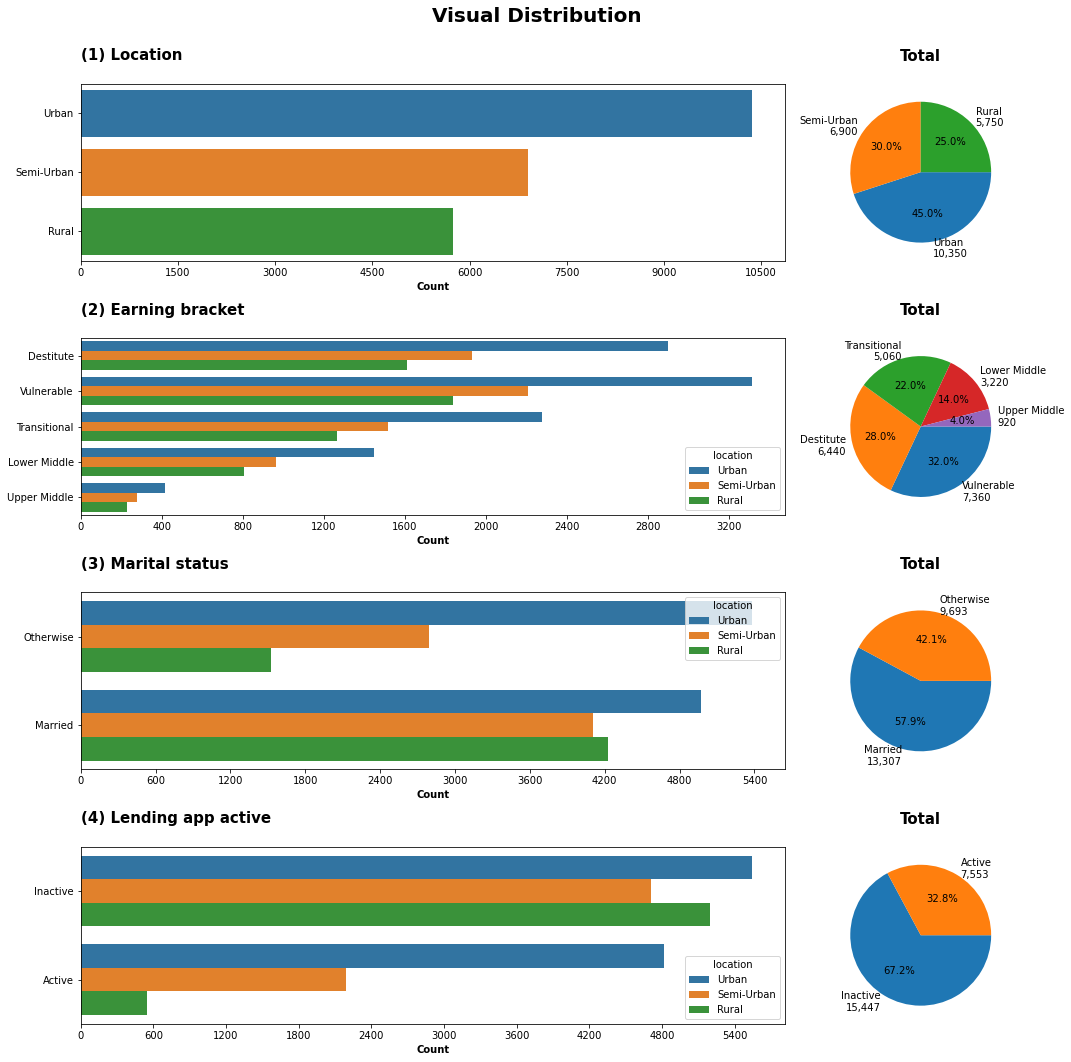

In [ ]:
# Visual univariate analaysis on categorical features

fig = plt.figure(8, figsize=(15,15), layout='tight')
fig.suptitle('Visual Distribution\n', fontsize=20, fontweight='bold')
gs = plt.GridSpec(4, 2, figure = fig, width_ratios = [4, 1])

for idx, axes in enumerate(gs):

    ax = fig.add_subplot(axes)
    if idx % 2 == 0:
        ax.set_title(
            f'({str(idx // 2 + 1)}) ' + master_df_cat.columns[idx // 2].replace(
                '_', ' ').capitalize() + '\n', x=0, ha='left',
            fontsize=15, fontweight='bold')
        sns.countplot(
            data=master_df, y=master_df_cat.columns[idx // 2], ax=ax,
            hue='location' if master_df_cat.columns[idx // 2] !='location' else None)
        ax.set_ylabel(None)
        ax.set_xlabel('Count', fontsize=10, weight='bold')
        ax.xaxis.set_major_locator(MNL(integer = True))


    else:
        portion = master_df_cat[master_df_cat.columns[idx // 2]].value_counts()
        ax.set_title('Total\n', size = 15, weight = 'bold')
        ax.pie(
            portion, startangle=0, counterclock=False, autopct='%1.1f%%',
            labels=[
                f'{label}\n{value:,}' for label, value
                in zip(portion.index, portion)], textprops={'fontsize': 10})
        ax.axis('off')

plt.show()

#### Numeric Data

In [ ]:
# Non-visual analysis on numeric features
pd.concat((
    master_df_num.describe().T,
    master_df_num.skew().rename('skew'),
    master_df_num.kurt().rename('kurt')), axis=1)

,count,mean,std,min,25%,50%,75%,max,skew,kurt
annual_income,23000.0,869719.227762,1.285593e+06,340.41,193590.95750,454392.4350,934313.72000,11944754.95,3.954722,19.320550
parity_ppp,23000.0,3038.720260,4.804766e+03,0.68,643.91375,1636.2325,3452.27625,58008.27,4.286568,24.105358
age,23000.0,32.715000,9.525868e+00,20.00,25.00000,31.0000,39.00000,65.00,0.831020,0.010667
household_dependents,23000.0,4.455043,2.479916e+00,0.00,3.00000,4.0000,6.00000,15.00,0.559746,0.162652
telecom_monthly_spend,23000.0,4883.572693,5.602552e+03,404.53,1648.17750,2970.7050,5752.17750,60051.37,3.151136,13.819645
betting_monthly_freq,23000.0,3.971043,3.276301e+00,0.00,1.00000,3.0000,6.00000,23.00,1.214461,1.659624
betting_monthly_spend,23000.0,5377.713233,1.838767e+04,0.00,1485.18500,2725.7400,4770.83500,225575.18,9.364273,88.720888
credit_score,23000.0,602.891609,7.836115e+01,300.00,552.00000,602.0000,661.00000,796.00,-0.386951,0.538107


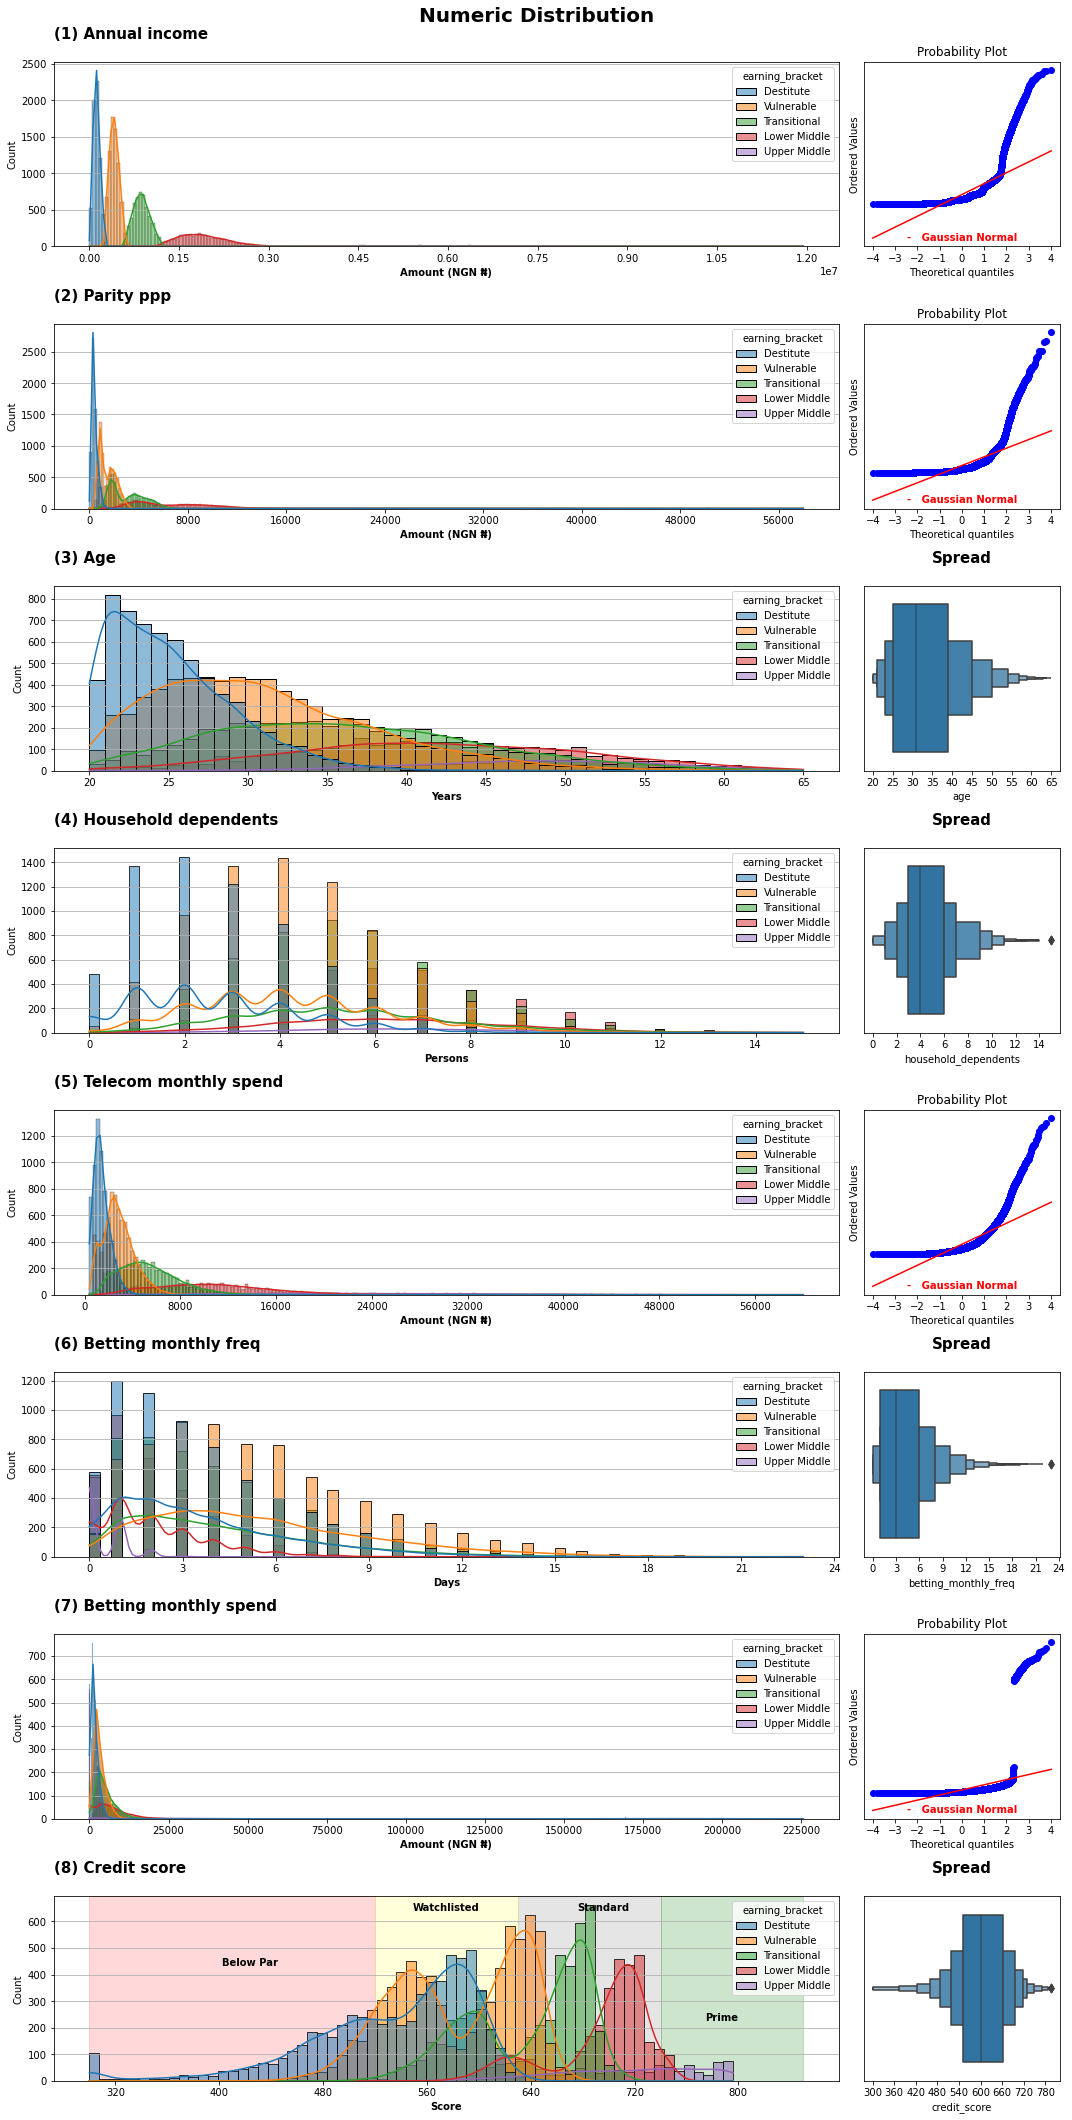

CPU times: total: 1min 36s
Wall time: 1min 22s


In [ ]:
%%time

# Visual unvariate analysis on numeric features

fig = plt.figure(16, figsize=(15,30), layout='tight')
fig.suptitle('Numeric Distribution\n', fontsize=20, fontweight='bold')
gs = plt.GridSpec(8, 2, figure = fig, width_ratios = [4, 1])

for idx, axes in enumerate(gs):

    ax = fig.add_subplot(axes)
    if idx % 2 == 0:
        ax.set_title(
            f'({str(idx // 2 + 1)}) ' + master_df_num.columns[idx // 2].replace(
                '_', ' ').capitalize() + '\n', x=0, ha='left',
            fontsize=15, fontweight='bold')
        if idx // 2 == 7:
            ax.axvspan(xmin=300, xmax=520, alpha=0.15, color='red')
            ax.axvspan(xmin=520, xmax=630, alpha=0.15, color='yellow')
            ax.axvspan(xmin=630, xmax=740, alpha=0.20, color='grey')
            ax.axvspan(xmin=740, xmax=850, alpha=0.20, color='green')
            ax.annotate(
                'Below Par', fontsize=10, fontweight='bold',
            color='black', ha='center', va='center', xy=(300, 0),
            textcoords='axes fraction', xytext=(0.25, 0.64))
            ax.annotate(
                'Watchlisted', fontsize=10, fontweight='bold',
            color='black', ha='center', va='center', xy=(300, 0),
            textcoords='axes fraction', xytext=(0.5, 0.94))
            ax.annotate(
                'Standard', fontsize=10, fontweight='bold',
            color='black', ha='center', va='center', xy=(300, 0),
            textcoords='axes fraction', xytext=(0.7, 0.94))
            ax.annotate(
                'Prime', fontsize=10, fontweight='bold',
            color='black', ha='center', va='center', xy=(300, 0),
            textcoords='axes fraction', xytext=(0.85, 0.34))

        sns.histplot(
            data=master_df,
            x=master_df_num.columns[idx // 2], kde=True,
            hue='earning_bracket', ax=ax)
        ax.set_xlabel(
            f'Amount (NGN {chr(8358)})' if master_df_num.columns[idx // 2]
            in master_df_num.select_dtypes('float64').columns else 'Days' if
            master_df_num.columns[idx // 2] == 'betting_monthly_freq'
            else 'Years' if master_df_num.columns[idx // 2] == 'age'
            else 'Persons' if master_df_num.columns[idx // 2] == 'household_dependents'
            else 'Score',
            fontsize=10, weight='bold')
        ax.grid(True, axis='y')
        ax.xaxis.set_major_locator(MNL(integer = True))

    else:
        if master_df_num.columns[idx // 2] in master_df_num.select_dtypes(
            'float64').columns:
            ax.annotate(
                '-   Gaussian Normal', fontsize=10, fontweight='bold',
                color='red', ha='center', va='center', xy=(0, 0),
                textcoords='axes fraction', xytext=(0.5, 0.05))
            stats.probplot(
                master_df_num[master_df_num.columns[idx // 2]],
                dist=stats.norm, plot=ax)
        else:
            ax.set_title(
                'Spread\n', fontsize=15, fontweight='bold')
            sns.boxenplot(
                data=master_df_num, x=master_df_num.columns[idx // 2], ax=ax)
        ax.set_yticks([])
        ax.xaxis.set_major_locator(ticker.MultipleLocator(
            master_df_num[master_df_num.columns[idx // 2]].max() / 4))
        ax.xaxis.set_major_locator(MNL(integer = True))

plt.show()

#### Eligiblity Distribution

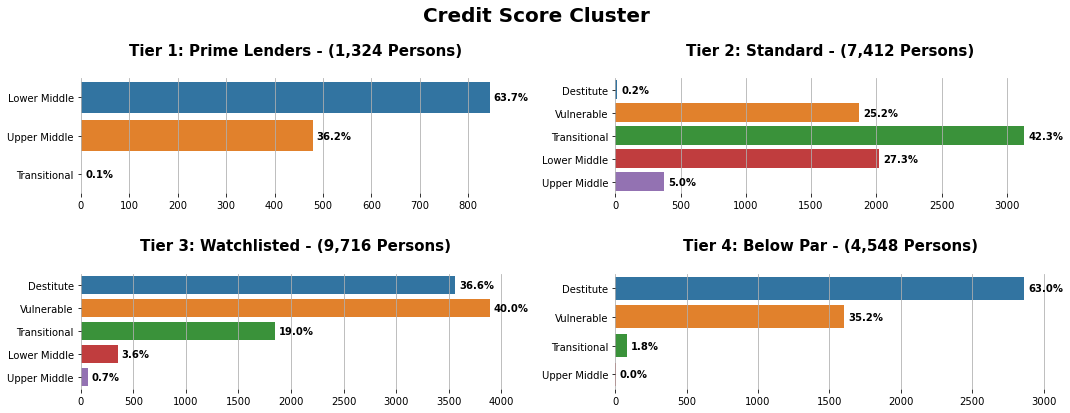

In [ ]:
criteria = {3: [master_df.credit_score < 540, 'Below Par'],
            2: [(master_df.credit_score >= 540) &
                (master_df.credit_score < 630), 'Watchlisted'],
            1: [(master_df.credit_score >= 630) &
                (master_df.credit_score < 720), 'Standard'],
            0: [master_df.credit_score >= 720, 'Prime Lenders']}

fig = plt.figure(4, figsize=(15,6), layout='tight')
fig.suptitle('Credit Score Cluster', fontsize=20, fontweight='bold', y=0.95)
gs = plt.GridSpec(2, 2, figure = fig, )

for idx, axes in enumerate(gs):
    ax = fig.add_subplot(axes)
    data = master_df[criteria[idx][0]]
    ax.set_title(
        f'\nTier {str(idx + 1)}: {criteria[idx][1]} - ('+
        f'{data.shape[0]:,} Persons)\n', fontsize=15, fontweight='bold')
    label = [
        f'{value / data.shape[0]:.1%}' for value in
        data.earning_bracket.value_counts(sort=False).values]
    sns.countplot(data=data, y='earning_bracket', ax=ax)
    ax.bar_label(
        ax.containers[0], labels=label, padding=4, fontsize=10,
        weight='bold')
    ax.set_frame_on(False)
    ax.grid(True, axis='x')
    ax.set_ylabel(None)
    ax.set_xlabel(None)

plt.show();

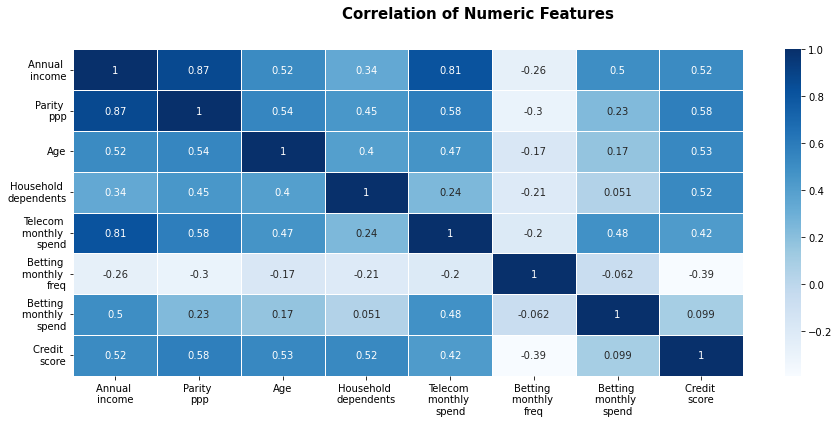

In [ ]:
# Bivariate analysis on numeric features

fig = plt.figure(1, figsize=(15, 6))
fig.suptitle('Correlation of Numeric Features', fontsize=15, weight='bold')

sns.heatmap(
    master_df_num.corr(), annot = True, cmap='Blues',
    linecolor = 'white', linewidths=1, xticklabels=[
        col.replace('_', ' \n').capitalize() for col in master_df_num.columns],
    yticklabels=[
        col.replace('_', ' \n').capitalize() for col in master_df_num.columns])

plt.show();


#### Observation:

Apart from the fairly strong correlation between applicant's annual income, income parity (ppp) and telecom monthly spend, there appears to be little room for model bias due to multicolinearity. Also, any possible bias due to multicolinearity between these features was cured in the ratioes and matrices used for deriving the target variable. Thus, the model will predict credit scores based on already scored credit data.


### Model Development

#### Model Data Preparation

In [ ]:
# Split data by columns into input and target features
X = master_df.drop('credit_score', axis=1)
y = master_df.credit_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69)

print('Justification (80-20 split): \n\n{} {}\n{} {}\n\n{}'.format(
    f'{X_train.shape[0]:,}', 'for Training', f'{X_test.shape[0]:,}', 'for Testing',
    'A hundred thousand records is sufficient for testing!'))

Justification (80-20 split): 

18,400 for Training
4,600 for Testing

A hundred thousand records is sufficient for testing!


In [ ]:
# Initialise transformers
scaler_std = StandardScaler()
encode_hot = OneHotEncoder(
    handle_unknown='ignore', drop='first', sparse_output=False)

bracket = ['Destitute', 'Vulnerable', 'Transitional',
           'Lower Middle', 'Upper Middle']
lending = ['Inactive', 'Active']
encode_ord = OrdinalEncoder(
    categories = [bracket, lending], unknown_value=-1,
    handle_unknown='use_encoded_value', encoded_missing_value=-5)

# Define data preprocessor
preprocessor = ColumnTransformer(transformers = [
    ('LB', encode_hot, ['location', 'marital_status']),
    ('OD', encode_ord, ['earning_bracket', 'lending_app_active']),
    ('NB', scaler_std, list(master_df_num.columns[:-1]))])


In [ ]:
# Examine preprocessor X_train data
X_train_transformed = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out())


#### Pipeline Assembly

For accuracy and efficiency, multiple models are trained in pipeline namely:

1. Linear Regressor
2. Ridge Regressor
3. K-Neighbours Regressor
4. Decision Trees Regressor
5. Random Forest Regressor

The best performing model will be adopted for deployment

In [ ]:
%%time

# Initialise models
models = {
    'linear': LinearRegression(),
    'ridge': Ridge(),
    'kneighbours': KNeighborsRegressor(),
    'decisiontrees': DecisionTreeRegressor(),
    'randomforest': RandomForestRegressor()}

# Define constraints for wrapping models
def identify(y):
    return y
def apply_constraints(y):
    return np.clip(y, 300, 850).astype(int)

# Train model
trained_pipes = {}
for name, model in models.items():
    constrained_model = TransformedTargetRegressor(
        regressor=model, func=identify, inverse_func=apply_constraints)
    pipe = Pipeline(steps = [
        ('preprocessor', preprocessor), ('model', constrained_model)])
    pipe.fit(X_train, y_train)
    trained_pipes[name] = pipe


CPU times: total: 23.7 s
Wall time: 22.7 s


#### Model Prediction

In [ ]:
%%time

# Test the model on testing data
testing = {'actual': y_test}
[
    testing.update({item: trained_pipes[item].predict(X_test)})
    for item in models]
testing = pd.DataFrame(testing)

# Check the model on training data
training = {'actual': y_train}
[
    training.update({item: trained_pipes[item].predict(X_train)})
    for item in models]
training = pd.DataFrame(training)


CPU times: total: 7.91 s
Wall time: 6.29 s


#### Model Evaluation

In [ ]:
# Collated outputs on testing predictions for each model
testing

,actual,linear,ridge,kneighbours,decisiontrees,randomforest
19932,625,615,615,620,623,623
14329,650,632,631,642,647,647
5840,555,535,535,556,554,555
1094,479,552,552,564,482,484
16380,715,711,711,716,715,714
...,...,...,...,...,...,...
3369,615,612,612,624,613,612
19392,599,599,599,594,606,597
21304,680,680,680,680,679,679
20157,587,591,591,602,587,588


In [ ]:
# Collated outputs on training predictions for each model
training

,actual,linear,ridge,kneighbours,decisiontrees,randomforest
4707,525,526,526,544,525,526
9254,708,709,709,706,708,707
22675,726,741,741,724,726,725
9966,691,666,666,691,691,692
2093,553,504,504,484,553,550
...,...,...,...,...,...,...
4374,509,519,519,526,509,508
11825,590,575,575,584,590,589
14740,691,677,677,686,691,691
9818,710,714,714,707,710,710


In [ ]:
# Get test evaluation metrics and residuals
test_residuals = pd.DataFrame({})
test_matrix = {'MAE': {}, 'RMSE': {}}

for key in models.keys():
    test_residuals[key] = testing['actual'] - testing[key]
    test_matrix['MAE'][key] = mean_absolute_error(y_test, testing[key])
    test_matrix['RMSE'][key] = np.sqrt(
        mean_squared_error(y_test, testing[key]))

# Get train evaluation metrics and residuals
train_residuals = pd.DataFrame({})
train_matrix = {'MAE': {}, 'RMSE': {}}

for key in models.keys():
    train_residuals[key] = training['actual'] - training[key]
    train_matrix['MAE'][key] = mean_absolute_error(y_train, training[key])
    train_matrix['RMSE'][key] = np.sqrt(
        mean_squared_error(y_train, training[key]))

pd.concat((pd.Series(test_matrix['MAE']).rename('MAE_testing'),
    pd.Series(train_matrix['MAE']).rename('MAE_training')), axis=1)


,MAE_testing,MAE_training
linear,17.017391,16.782228
ridge,17.015652,16.781522
kneighbours,14.157391,11.283207
decisiontrees,4.308261,0.000000
randomforest,3.077826,1.211957


In [ ]:
pd.concat((pd.Series(test_matrix['RMSE']).rename('RMSE_testing'),
    pd.Series(train_matrix['RMSE']).rename('RMSE_training')), axis=1)


,RMSE_testing,RMSE_training
linear,29.089823,28.717525
ridge,29.088336,28.717689
kneighbours,27.102094,21.915910
decisiontrees,8.850743,0.000000
randomforest,6.271121,2.220409


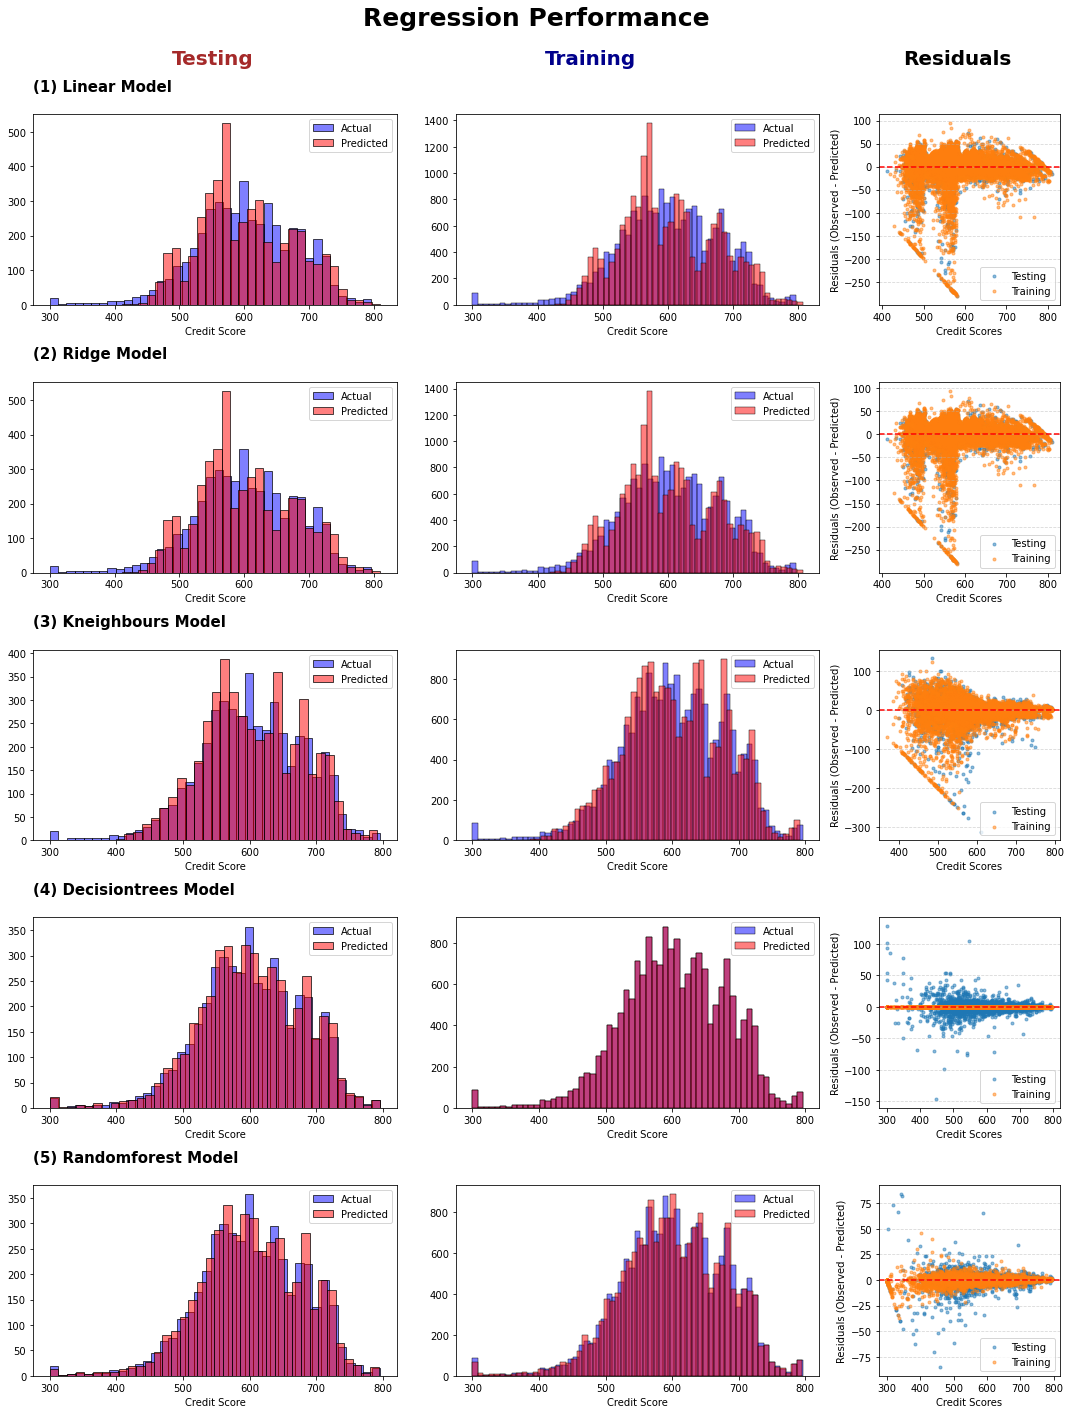

In [ ]:
# Visual analysis on performance in esting and training

fig = plt.figure(15, figsize=(15,20), layout='tight')
fig.suptitle('Regression Performance\n\n', fontsize=25, fontweight='bold')
gs = plt.GridSpec(5, 3, figure = fig, width_ratios = [2, 2, 1])
fig.text(0.2, 0.94, 'Testing', size = 20, weight = 'bold', ha = 'center', color = 'brown')
fig.text(0.55, 0.94, 'Training', size = 20, weight = 'bold', ha = 'center', color = 'darkblue')
fig.text(0.89, 0.94, 'Residuals', size = 20, weight = 'bold', ha = 'center', color = 'black')

for idx, axes in enumerate(gs):

    ax = fig.add_subplot(axes)
    if idx % 3 == 0:
        ax.set_title(f'({str(idx // 3 + 1)}) ' +
            list(models.keys())[idx // 3].capitalize() +
            ' Model\n', x=0, ha='left', fontsize=15, fontweight='bold')
        sns.histplot(
            testing['actual'], color='blue', alpha=0.5, label='Actual',
            ax=ax), sns.histplot(testing[testing.columns[idx // 3 + 1]],
            color='red', alpha=0.5, label='Predicted', ax=ax)
        ax.set_ylabel(None)
        ax.set_xlabel('Credit Score', fontsize=10)
        plt.legend(loc=1)

    elif idx % 3 == 1:
        sns.histplot(
            training['actual'], color='blue', alpha=0.5, label='Actual',
            ax=ax), sns.histplot(training[training.columns[idx // 3 + 1]],
            color='red', alpha=0.5, label='Predicted', ax=ax)
        ax.set_ylabel(None)
        ax.set_xlabel('Credit Score', fontsize=10)
        plt.legend(loc=1)

    else:
        ax.scatter(
            testing[testing.columns[idx // 3 + 1]],
            test_residuals[test_residuals.columns[idx // 3]],
            marker='.', alpha=0.5, label='Testing')
        ax.scatter(
            training[training.columns[idx // 3 + 1]],
            train_residuals[train_residuals.columns[idx // 3]],
            marker='.', alpha=0.5, label='Training')
        ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
        ax.set_xlabel('Credit Scores', fontsize=10)
        ax.set_ylabel('Residuals (Observed - Predicted)', fontsize=10)
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)
        ax.legend(loc=4)

plt.show();

#### Observation

Of the 5 models developed, the choice model to adopt for deployment is the Random Forest Regressor due to the following reasons:

1. It has the least Mean Absolute Error in Testing and the second lowest in Training (after Decision Trees Regressor)
2. It also has the least Root Mean Square Error in Testing and the second lowest in Training (again after Decision Trees Regressor)
3. It shows no indication of over-fitting either in Testing and in Training (as is the case with after Decision Trees Regressor)
4. The residuals are the most evenly distributed in the residual plot judging by its preditctions both in Testing and in Training  
5. The predictions remain within the constraints of Credit Score Card 300 - 850


### Model Deployment

In [ ]:
# Select preferred model
chosen_model = trained_pipes['randomforest']

In [ ]:
# Strip possible attributes attached to model
if hasattr(chosen_model, 'estimators_'):
    for estimator in chosen_model.estimators_:
        estimator.data = None

In [ ]:
# Save the trained model
joblib.dump(
    chosen_model, 'Streamlit_files/random_forest_model.pkl',
    compress=3)

# Save the scaler
joblib.dump(scaler_std, 'Streamlit_files/scaler.pkl')

# Save the encoders
joblib.dump(encode_hot, 'Streamlit_files/hot_encoder.pkl')
joblib.dump(encode_ord, 'Streamlit_files/ord_encoder.pkl')

print("Model, scaler, and both encoder saved successfully!")